In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("mumbai-house-price-data-cleaned.csv")

In [3]:
df.head()

,title,price,area,price_per_sqft,locality,city,property_type,bedroom_num,bathroom_num,balcony_num,furnished,age,total_floors,latitude,longitude
0,Octave Parijas Horizon,6600283,757,8719.000000,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.244410,73.123253
1,Shakti Siyara Heights,6169841,652,9462.946319,Kalyan,Mumbai,Apartment,2,2,0,Unfurnished,0,1,19.257294,73.148872
2,Bhagwati Bhagwati Celeste,4599936,396,11616.000000,Dombivali,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.209026,73.081276
3,Relcon Ridhi Sidhi Sadan Of Ridhi Sidhi Co Ope...,51980000,1130,46000.000000,Ville Parle,Mumbai,Apartment,3,3,0,Unfurnished,0,1,19.097841,72.851158
4,J P Ruchita Bliss,3915000,435,9000.000000,Nala Sopara,Mumbai,Apartment,1,1,0,Unfurnished,0,1,19.420601,72.809319


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71938 entries, 0 to 71937
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           71938 non-null  object 
 1   price           71938 non-null  int64  
 2   area            71938 non-null  int64  
 3   price_per_sqft  71938 non-null  float64
 4   locality        71938 non-null  object 
 5   city            71938 non-null  object 
 6   property_type   71938 non-null  object 
 7   bedroom_num     71938 non-null  int64  
 8   bathroom_num    71938 non-null  int64  
 9   balcony_num     71938 non-null  int64  
 10  furnished       71938 non-null  object 
 11  age             71938 non-null  int64  
 12  total_floors    71938 non-null  int64  
 13  latitude        71938 non-null  float64
 14  longitude       71938 non-null  float64
dtypes: float64(3), int64(7), object(5)
memory usage: 8.2+ MB


In [5]:
df.describe()

,price,area,price_per_sqft,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude
count,7.193800e+04,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000,71938.000000
mean,1.951272e+07,943.251369,18489.401813,1.993884,2.082432,0.164336,2.247852,1.004740,19.171970,72.964390
std,3.320767e+07,645.881922,12691.857370,0.914573,0.854540,0.593804,4.230751,0.381272,0.465753,0.406728
min,3.200000e+04,123.000000,25.376685,0.000000,1.000000,0.000000,0.000000,1.000000,12.889899,72.435379
25%,6.524250e+06,595.000000,9230.769231,1.000000,2.000000,0.000000,0.000000,1.000000,19.071314,72.858833
50%,1.200000e+07,775.000000,16080.402010,2.000000,2.000000,0.000000,0.000000,1.000000,19.164281,72.916528
75%,2.150000e+07,1100.000000,23913.043478,3.000000,2.000000,0.000000,3.000000,1.000000,19.229946,73.021536
max,2.147484e+09,24109.000000,290000.000000,15.000000,15.000000,15.000000,57.000000,70.000000,72.868339,91.804413


In [6]:
df.isnull().sum()

,0
title,0
price,0
area,0
price_per_sqft,0
locality,0
city,0
property_type,0
bedroom_num,0
bathroom_num,0
balcony_num,0


In [7]:
df.columns

Index(['title', 'price', 'area', 'price_per_sqft', 'locality', 'city',
       'property_type', 'bedroom_num', 'bathroom_num', 'balcony_num',
       'furnished', 'age', 'total_floors', 'latitude', 'longitude'],
      dtype='object')

In [8]:
df.columns = df.columns.str.strip().str.lower()

In [9]:
df = df.drop(columns=['title'])

In [10]:
df.columns

Index(['price', 'area', 'price_per_sqft', 'locality', 'city', 'property_type',
       'bedroom_num', 'bathroom_num', 'balcony_num', 'furnished', 'age',
       'total_floors', 'latitude', 'longitude'],
      dtype='object')

In [11]:
df['price'].head()

,price
0,6600283
1,6169841
2,4599936
3,51980000
4,3915000


In [12]:
df['price_lakhs'] = df['price'] / 100000

In [13]:
df[['price', 'price_lakhs']].head()

,price,price_lakhs
0,6600283,66.00283
1,6169841,61.69841
2,4599936,45.99936
3,51980000,519.80000
4,3915000,39.15000


In [14]:
df['area'].head()

,area
0,757
1,652
2,396
3,1130
4,435


In [15]:
df['calculated_price_per_sqft'] = df['price'] / df['area']

In [16]:
df[['price_per_sqft', 'calculated_price_per_sqft']].head()

,price_per_sqft,calculated_price_per_sqft
0,8719.000000,8719.000000
1,9462.946319,9462.946319
2,11616.000000,11616.000000
3,46000.000000,46000.000000
4,9000.000000,9000.000000


In [17]:
df = df.drop(columns=['price_per_sqft'])
df = df.rename(columns={'calculated_price_per_sqft': 'price_per_sqft'})

In [18]:
df[['price_lakhs', 'area', 'price_per_sqft']].describe()

,price_lakhs,area,price_per_sqft
count,71938.000000,71938.000000,71938.000000
mean,195.127178,943.251369,18489.401813
std,332.076653,645.881922,12691.857370
min,0.320000,123.000000,25.376685
25%,65.242500,595.000000,9230.769231
50%,120.000000,775.000000,16080.402010
75%,215.000000,1100.000000,23913.043478
max,21474.836470,24109.000000,290000.000000


In [19]:
df = df[df['price_lakhs'] < df['price_lakhs'].quantile(0.99)]

df = df[df['area'] < df['area'].quantile(0.99)]

df = df[df['price_per_sqft'] < df['price_per_sqft'].quantile(0.99)]

In [20]:
df = df[df['price_per_sqft'] > 1000]

In [21]:
df.describe()

,price,area,bedroom_num,bathroom_num,balcony_num,age,total_floors,latitude,longitude,price_lakhs,price_per_sqft
count,6.973800e+04,69738.000000,69738.000000,69738.000000,69738.000000,69738.000000,69738.000000,69738.000000,69738.000000,69738.000000,69738.000000
mean,1.621308e+07,881.564484,1.935286,2.027288,0.157920,2.230204,1.004015,19.174807,72.966611,162.130834,17536.952148
std,1.528987e+07,429.333311,0.830597,0.768677,0.558979,4.206703,0.379298,0.465997,0.410776,152.898744,10531.592555
min,4.500000e+05,123.000000,0.000000,1.000000,0.000000,0.000000,1.000000,12.889899,72.447647,4.500000,1031.111111
25%,6.500000e+06,590.000000,1.000000,2.000000,0.000000,0.000000,1.000000,19.074051,72.860971,65.000000,9143.331034
50%,1.160624e+07,756.000000,2.000000,2.000000,0.000000,0.000000,1.000000,19.168226,72.925079,116.062370,15903.000000
75%,2.000000e+07,1080.000000,2.000000,2.000000,0.000000,3.000000,1.000000,19.231569,73.023041,200.000000,23246.019871
max,1.285000e+08,2793.000000,7.000000,7.000000,5.000000,57.000000,70.000000,72.868339,91.804413,1285.000000,56910.998639


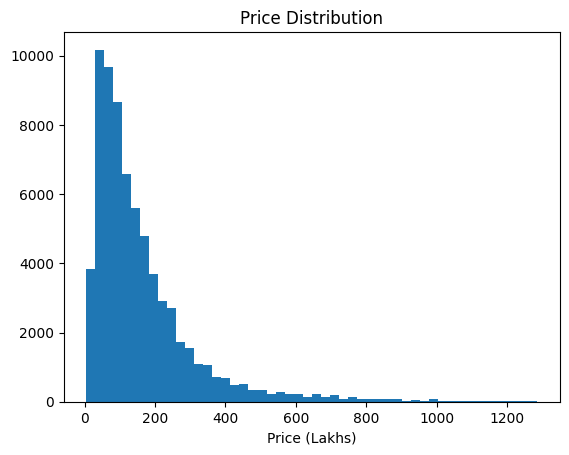

In [22]:
import matplotlib.pyplot as plt

plt.hist(df['price_lakhs'], bins=50)
plt.title("Price Distribution")
plt.xlabel("Price (Lakhs)")
plt.show()

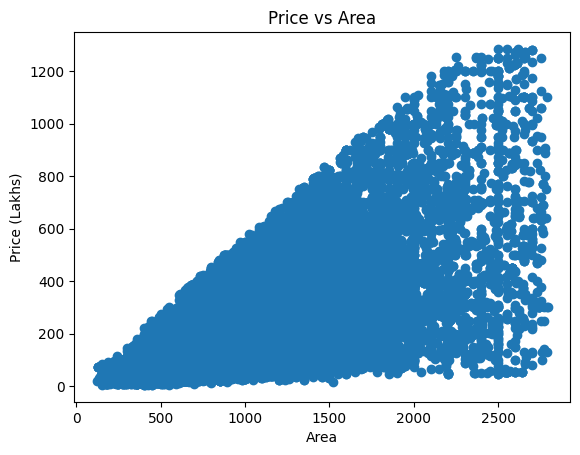

In [23]:
plt.scatter(df['area'], df['price_lakhs'])
plt.xlabel("Area")
plt.ylabel("Price (Lakhs)")
plt.title("Price vs Area")
plt.show()

In [24]:
df.groupby('locality')['price_per_sqft'].mean().sort_values(ascending=False).head(10)

,price_per_sqft
locality,
Mount Marry,56910.569106
Jvpd Scheme,55000.000000
Perry Cross Rd,53846.153846
Lokhandwala Andheri,53593.272171
Hiranandani Gardens Powai,51063.720483
Juhu Tara,50000.000000
Worli Sea Fase,49391.724991
Cumballa Hill,49132.772696
Malabar Hill,48215.742591


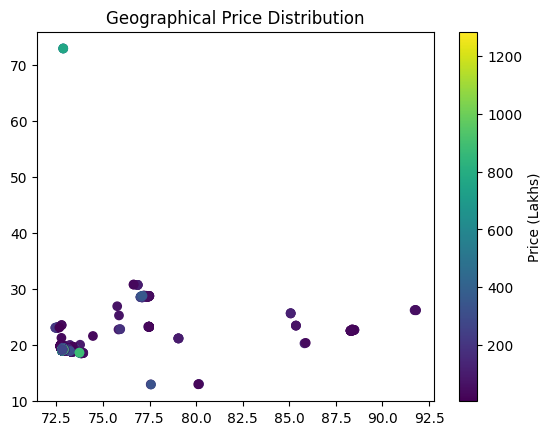

In [25]:
plt.scatter(df['longitude'], df['latitude'], c=df['price_lakhs'], cmap='viridis')
plt.colorbar(label='Price (Lakhs)')
plt.title("Geographical Price Distribution")
plt.show()

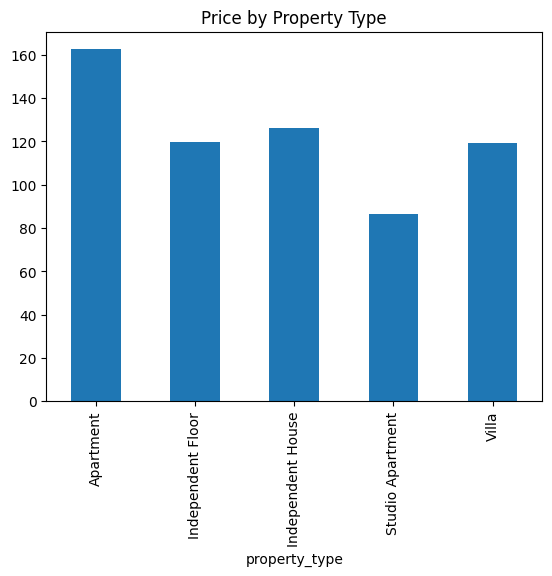

In [26]:
df.groupby('property_type')['price_lakhs'].mean().plot(kind='bar')
plt.title("Price by Property Type")
plt.show()

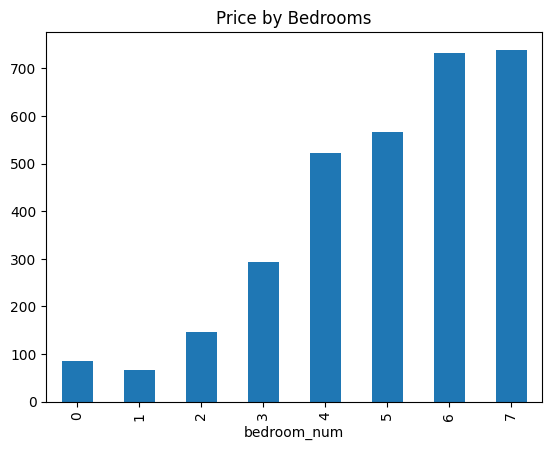

In [27]:
df.groupby('bedroom_num')['price_lakhs'].mean().plot(kind='bar')
plt.title("Price by Bedrooms")
plt.show()

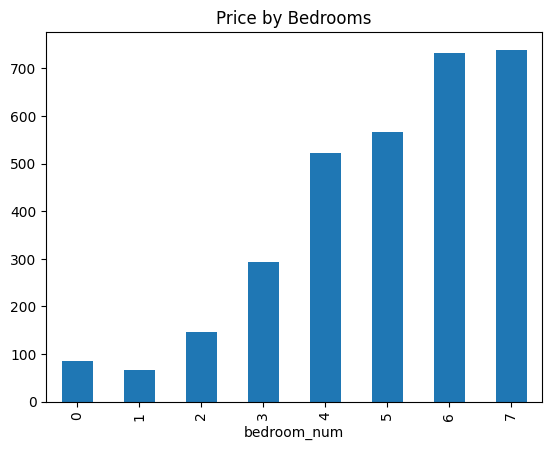

In [28]:
df.groupby('bedroom_num')['price_lakhs'].mean().plot(kind='bar')
plt.title("Price by Bedrooms")
plt.show()

In [29]:
df['bhk_category'] = df['bedroom_num'].apply(lambda x:
                                             'Small' if x <= 2 else
                                             'Medium' if x <= 4 else
                                             'Large')

In [30]:
df['age_category'] = df['age'].apply(lambda x:
                                     'New' if x <= 5 else
                                     'Mid' if x <= 15 else
                                     'Old')

In [31]:
df['floor_ratio'] = df['total_floors'] / (df['bedroom_num'] + 1)

In [32]:
df['price_segment'] = df['price_lakhs'].apply(lambda x:
                                              'Low' if x < 100 else
                                              'Mid' if x < 300 else
                                              'High')

In [33]:
top_localities = df.groupby('locality')['price_per_sqft'] \
                   .mean() \
                   .sort_values(ascending=False) \
                   .head(20) \
                   .index

df['is_premium_location'] = df['locality'].apply(
    lambda x: 1 if x in top_localities else 0
)

In [34]:
features = [
    'area', 'bedroom_num', 'bathroom_num',
    'balcony_num', 'latitude', 'longitude', 'is_premium_location'
]

X = df[features]
y = df['price_lakhs']

In [35]:
df['is_premium_location'].head()

,is_premium_location
0,0
1,0
2,0
3,0
4,0


In [36]:
df['is_premium_location'].value_counts()

,count
is_premium_location,
0,69353
1,385


In [37]:
top_localities = df.groupby('locality')['price_per_sqft'] \
                   .mean() \
                   .sort_values(ascending=False) \
                   .head(50) \
                   .index

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.5604412030296881


In [39]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.9392800984104972


In [40]:
df.to_csv("cleaned_mumbai_data.csv", index=False)